# Dependency Packages

In [132]:
import mne
import numpy as np
from mne.channels import make_standard_montage
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold , train_test_split , GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import os

# Parameter Setting

In [133]:
# GDF read dir path
# Dataset = f"BCICIV_2a_gdf"  # bci4_2A
Dataset = f"BCICIV_2b_gdf"  # bci4_2B
gdf_dirPath = f'../../dataset/{Dataset}/'

# EEG-MI 受試者
participants = []
participantsNum = 9
for i in range(1,participantsNum+1,1):
    # participants = participants + [f'A0{i}T']  # bci4_2A
    participants = participants + [f'B0{i}03T']  # bci4_2B

# Result store dir path
# saveResultPath = './result_bci4_2a/'  # bci4_2A
saveResultPath = './result_bci4_2b/'  # bci4_2B
try:
    os.mkdir(saveResultPath)
except:
    print("file exist")
    pass

# band pass filter
sfreq = 250
lowcut = 7
highcut = 30
filter_order = 4
filter_type = 'butter' # Butterworth
iir_params = dict(order=filter_order, ftype=filter_type)

# 769 左手, 770右手
target_keys = ['769', '770']  # bci4_2a and 2b

# 擷取實驗時間，0秒是cued開始
tmin = 0
tmax = 4

# CSP M值
M = 3

# BCI4 2A 資料集電擊轉換成標準10-20系統
# channel_rename_map = {
#     'EEG-Fz' : 'Fz'  ,
#     'EEG-0'  : 'FC3' ,
#     'EEG-1'  : 'FC1' ,
#     'EEG-2'  : 'FCz' ,
#     'EEG-3'  : 'FC2' ,
#     'EEG-4'  : 'FC4' ,
#     'EEG-5'  : 'C5'  ,
#     'EEG-C3' : 'C3'  ,
#     'EEG-6'  : 'C1'  ,
#     'EEG-Cz' : 'Cz'  ,
#     'EEG-7'  : 'C2'  ,
#     'EEG-C4' : 'C4'  ,
#     'EEG-8'  : 'C6'  ,
#     'EEG-9'  : 'CP3' ,
#     'EEG-10' : 'CP1' ,
#     'EEG-11' : 'CPz' ,
#     'EEG-12' : 'CP2' ,
#     'EEG-13' : 'CP4' ,
#     'EEG-14' : 'P1'  ,
#     'EEG-Pz' : 'Pz'  ,
#     'EEG-15' : 'P2'  ,
#     'EEG-16' : 'POz' ,
#     'EOG-left'   : 'EOG-left',
#     'EOG-central': 'EOG-central',
#     'EOG-right'  : 'EOG-right'
# }
# channel_types = {
#     'EEG-Fz' : 'eeg',
#     'EEG-0'  : 'eeg',
#     'EEG-1'  : 'eeg',
#     'EEG-2'  : 'eeg',
#     'EEG-3'  : 'eeg',
#     'EEG-4'  : 'eeg',
#     'EEG-5'  : 'eeg',
#     'EEG-C3' : 'eeg',
#     'EEG-6'  : 'eeg',
#     'EEG-Cz' : 'eeg',
#     'EEG-7'  : 'eeg',
#     'EEG-C4' : 'eeg',
#     'EEG-8'  : 'eeg',
#     'EEG-9'  : 'eeg',
#     'EEG-10' : 'eeg',
#     'EEG-11' : 'eeg',
#     'EEG-12' : 'eeg',
#     'EEG-13' : 'eeg',
#     'EEG-14' : 'eeg',
#     'EEG-Pz' : 'eeg',
#     'EEG-15' : 'eeg',
#     'EEG-16' : 'eeg',
#     'EOG-left'   : 'eog',
#     'EOG-central': 'eog',
#     'EOG-right'  : 'eog'
# }

# BCI4 2B 資料集電擊轉換成標準10-20系統
channel_rename_map = {
    'EEG:C3' : 'C3'  ,
    'EEG:Cz' : 'Cz'  ,
    'EEG:C4' : 'C4'  ,
    'EOG:ch01':'EOG:ch01',
    'EOG:ch02':'EOG:ch02',
    'EOG:ch03':'EOG:ch03'
}
channel_types = {
    'EEG:C3'   : 'eeg',
    'EEG:Cz'   : 'eeg',
    'EEG:C4'   : 'eeg',
    'EOG:ch01' : 'eog',
    'EOG:ch02' : 'eog',
    'EOG:ch03' : 'eog'
}

file exist


# Filter

No data specified. Sanity checks related to the length of the signal relative to the filter order will be skipped.
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB



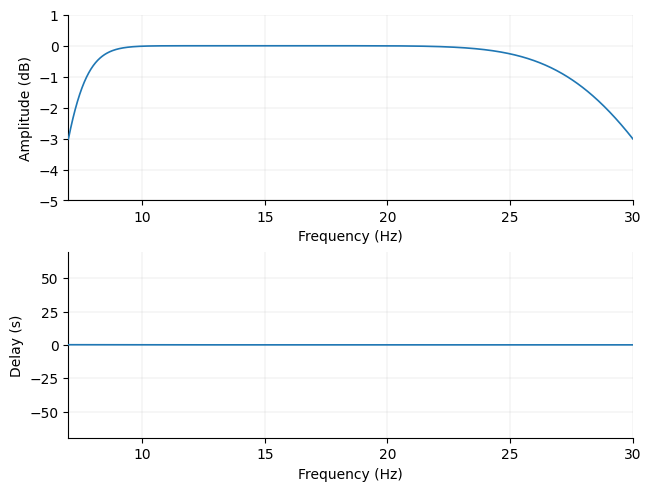

In [134]:
iir_coeffs = mne.filter.create_filter(
    data=None,           # data=None 時，僅計算係數
    sfreq=sfreq,
    l_freq=lowcut,
    h_freq=highcut,
    method='iir',
    iir_params=iir_params,
)

f = mne.viz.plot_filter(
    iir_coeffs,
    sfreq=sfreq,
    freq=[lowcut, highcut],
    fscale = "linear",
    alim = (-5,1),
    plot= ('magnitude', 'delay'),
    title=f'Butterworth Filter Frequency Response (Order={filter_order}, {lowcut}-{highcut} Hz)'
)
title=f'Butterworth Filter Frequency Response (Order={filter_order}, {lowcut}-{highcut} Hz)'
name = title.split(' ')
name = '_'.join(name) + ".png"
savePath = saveResultPath + f'./{name}'
f.savefig(savePath)

print()

# Data Segmentation and Splitting

In [135]:
montage = make_standard_montage('standard_1020')
eeg_only_channels = [
    name
    for name in channel_rename_map.values()
    if not name.startswith('EOG')
]

## Create Epoch training data and testing data
epochs_train = {}
epochs_test = {}
SEED = 42
for subject in participants:
    gdf_filepath = gdf_dirPath + f'./{subject}.gdf'
    try:
        raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)
        print("GDF 檔案讀取成功。")
    except Exception as e:
        print(f"讀取 GDF 檔案時發生錯誤: {e}")
        raise
    ## Raw setting
    raw.set_channel_types(channel_types)
    raw.set_eeg_reference([])
    raw.rename_channels(channel_rename_map)
    raw.set_montage(montage, on_missing='ignore')

    ## Regression
    model = mne.preprocessing.EOGRegression(picks='eeg', picks_artifact='eog')
    model.fit(raw)
    raw = model.apply(raw)

    ## Remove EOG data in Epoch
    raw.pick_channels(eeg_only_channels)

    ## Filter
    raw.filter(
        l_freq=lowcut,
        h_freq=highcut,
        method='iir',       # 指定使用 IIR 濾波器
        iir_params=dict(order=filter_order, ftype='butter')
    )

    ## 選取事件做成epoch
    events, event_id = mne.events_from_annotations(raw)
    kept_event_ids = {
        key: value
        for key, value in event_id.items()
        if key in target_keys
    }
    events_of_interest = events[np.isin(events[:, 2], list(kept_event_ids.values()))]
    baseline = None
    epochs = mne.Epochs(
        raw,
        events_of_interest,
        event_id=kept_event_ids,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True,        # 將數據載入內存
        proj=False           # 暫時不應用投影
    )

    ## Data splitting
    y_all = epochs.events[:, 2]
    indices = np.arange(len(epochs))
    train_indices, test_indices, _, _ = train_test_split(
        indices, y_all,
        test_size=0.2,
        random_state=SEED,
        stratify=y_all # 確保標籤比例均衡
    )
    epochs_train[subject] = epochs[train_indices]
    epochs_test[subject] = epochs[test_indices]

Extracting EDF parameters from d:\User\Desktop\EEGsProgram\dataset\BCICIV_2b_gdf\B0103T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG:C3, EEG:Cz, EEG:C4, EOG:ch01, EOG:ch02, EOG:ch03
Creating raw.info structure...
Reading 0 ... 469010  =      0.000 ...  1876.040 secs...


C:\Users\User\AppData\Local\Temp\ipykernel_21732\2861199202.py:15: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1077'), np.str_('1078'), np.str_('1079'), np.str_('1081'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('781')]
Not setting metadata
160 matching events found
No baseline correction applied
Using data from pr

C:\Users\User\AppData\Local\Temp\ipykernel_21732\2861199202.py:15: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1077'), np.str_('1078'), np.str_('1079'), np.str_('1081'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('781')]
Not setting metadata
160 matching events found
No baseline correction applied
Using data from pr

...

GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1077'), np.str_('1078'), np.str_('1079'), np.str_('1081'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('781')]
Not setting metadata
160 matching events found
No baseline correction applied
Using data from pr

C:\Users\User\AppData\Local\Temp\ipykernel_21732\2861199202.py:15: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1077'), np.str_('1078'), np.str_('1079'), np.str_('1081'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('781')]
Not setting metadata
160 matching events found
No baseline correction applied
Using data from pr

C:\Users\User\AppData\Local\Temp\ipykernel_21732\2861199202.py:15: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(gdf_filepath, preload=True)


GDF 檔案讀取成功。
EEG channel type selected for re-referencing
EEG data marked as already having the desired reference.
No projector specified for this dataset. Please consider the method self.add_proj.
No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 7.00, 30.00 Hz: -6.02, -6.02 dB

Used Annotations descriptions: [np.str_('1023'), np.str_('1077'), np.str_('1078'), np.str_('1079'), np.str_('1081'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770'), np.str_('781')]
Not setting metadata
160 matching events found
No baseline correction applied
Using data from pr

# CSP

In [136]:
## CSP training
csp_train_results = {}
csp_test_results = {}
csp_list = {} # 儲存訓練好的csp
for subject in participants:
    n_components = 2*M
    csp = CSP(
        n_components=n_components,
        reg=None, # 正則化參數，通常保持 None
        log=True,
        transform_into='average_power' # 轉換成平均功率 (方差的對數)
    )
    X = epochs_train[subject].get_data()
    y = epochs_train[subject].events[:, 2]
    X_csp = csp.fit_transform(X, y)
    csp_list[subject] = csp
    csp_train_results[subject] = {
        'X_csp': X_csp,
        'y_csp': y,
    }

## CSP testing
for subject in participants:
    csp = csp_list[subject]
    X = epochs_test[subject].get_data()
    y = epochs_test[subject].events[:, 2]
    X_csp = csp.transform(X)
    csp_test_results[subject] = {
        'X_csp': X_csp,
        'y_csp': y,
    }

Computing rank from data with rank=None
    Using tolerance 6.3e-07 (2.2e-16 eps * 3 dim * 9.4e+08  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=10 covariance using EMPIRICAL
Done.
Estimating class=11 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 5.2e-07 (2.2e-16 eps * 3 dim * 7.7e+08  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=10 covariance using EMPIRICAL
Done.
Estimating class=11 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 1e-06 (2.2e-16 eps * 3 dim * 1.6e+09  max singular value)
    Estimated rank (data): 3
    data: rank 3 computed from 3 data channels with 0 projectors
Reducing data rank from 3 -> 3
Estimating class=10 covariance using EMPIRICAL
Done.
Es

# Shape validation

In [137]:
print(f"subject: {subject}")
print(f"origin data shape: {epochs.get_data().shape}")
print(f"origin event shape: {epochs.events[:, 2].shape}")
print(f"training data shape: {epochs_train[subject].get_data().shape}")
print(f"training event shape: {epochs_train[subject].events[:,2].shape}")
print(f"testing data shape: {epochs_test[subject].get_data().shape}")
print(f"testing event shape: {epochs_test[subject].events[:,2].shape}")
print(f"csp training data shape: {csp_train_results[subject]['X_csp'].shape}")
print(f"csp testing data shape: {csp_test_results[subject]['X_csp'].shape}")

subject: B0903T
origin data shape: (160, 3, 1001)
origin event shape: (160,)
training data shape: (128, 3, 1001)
training event shape: (128,)
testing data shape: (32, 3, 1001)
testing event shape: (32,)
csp training data shape: (128, 3)
csp testing data shape: (32, 3)


# Machine Learning

In [138]:
# ML

# SEED = 42
# svm = SVC(probability=True, random_state=SEED)
best_models = {}
training_results = {}
## ML training
for subject in participants:
    print(f"Subject {subject} Training Start.")
    models = {
        "Linear_SVM": SVC(kernel='linear'),
        "RBF_SVM": SVC(kernel='rbf'), # 測試非線性
        "RandomForest": RandomForestClassifier(n_estimators=100),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "XGBoost": XGBClassifier(),
        "LDA": LinearDiscriminantAnalysis()
    }
    # 獲取訓練數據
    X_train = csp_train_results[subject]['X_csp']
    y_train = csp_train_results[subject]['y_csp']
    y_train = y_train - np.min(y_train)
    training_results[subject] = {}
    best_models[subject] = {}
    for name, model in models.items():
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)
        training_results[subject][name] = cv_scores.mean()
        model.fit(X_train, y_train)
        best_models[subject][name] = model

classification_results = {}
testing_results = {}
## ML testing
for subject in participants:
    print(f"Subject {subject} Testing Start.")
    X_test = csp_test_results[subject]['X_csp']
    y_test = csp_test_results[subject]['y_csp']
    y_test = y_test - np.min(y_test)
    classification_results[subject] = {}
    testing_results[subject] = {}
    for name, model in models.items():
        y_pred = best_models[subject][name].predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        testing_results[subject][name] = accuracy
        conf_matrix = confusion_matrix(y_test, y_pred)
        classification_results[subject][name] = conf_matrix

Subject B0103T Training Start.
Subject B0203T Training Start.
Subject B0303T Training Start.
Subject B0403T Training Start.
Subject B0503T Training Start.
Subject B0603T Training Start.
Subject B0703T Training Start.
Subject B0803T Training Start.
Subject B0903T Training Start.
Subject B0103T Testing Start.
Subject B0203T Testing Start.
Subject B0303T Testing Start.
Subject B0403T Testing Start.
Subject B0503T Testing Start.
Subject B0603T Testing Start.
Subject B0703T Testing Start.
Subject B0803T Testing Start.
Subject B0903T Testing Start.


# Results

In [139]:
df_train = pd.DataFrame(training_results)
print(f"training cv scores:")
print(df_train)
print()
df_test = pd.DataFrame(testing_results)
print(f"testing cv scores:")
print(df_test)
print()

training cv scores:
                B0103T    B0203T    B0303T    B0403T    B0503T    B0603T  \
Linear_SVM    0.788308  0.554769  0.507385  0.976923  0.835692  0.726462   
RBF_SVM       0.788000  0.538154  0.430462  0.976923  0.828000  0.742462   
RandomForest  0.749538  0.600615  0.452000  0.976308  0.812923  0.726769   
KNN           0.709846  0.585231  0.469231  0.968923  0.828000  0.726769   
XGBoost       0.773538  0.554462  0.451692  0.961231  0.804615  0.734462   
LDA           0.796308  0.532308  0.490769  0.976923  0.828000  0.734154   

                B0703T    B0803T    B0903T  
Linear_SVM    0.858769  0.866462  0.788615  
RBF_SVM       0.842769  0.820000  0.772923  
RandomForest  0.850154  0.812615  0.780923  
KNN           0.866154  0.788615  0.749846  
XGBoost       0.827692  0.828615  0.788308  
LDA           0.881846  0.851077  0.819385  

testing cv scores:
               B0103T   B0203T   B0303T  B0403T   B0503T   B0603T   B0703T  \
Linear_SVM    0.81250  0.53125  0.

# Result Plot

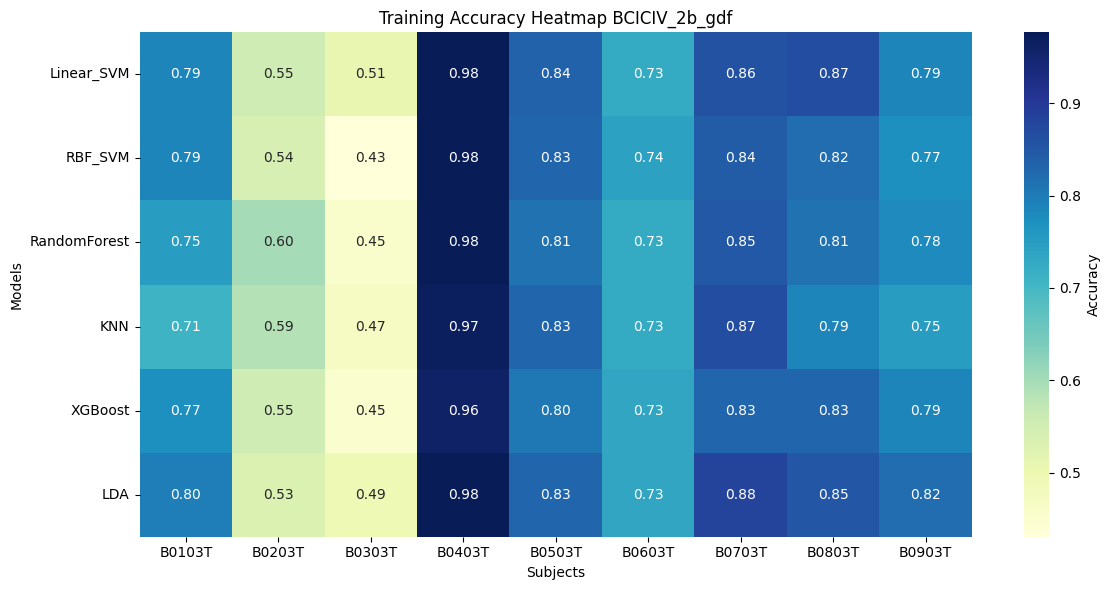

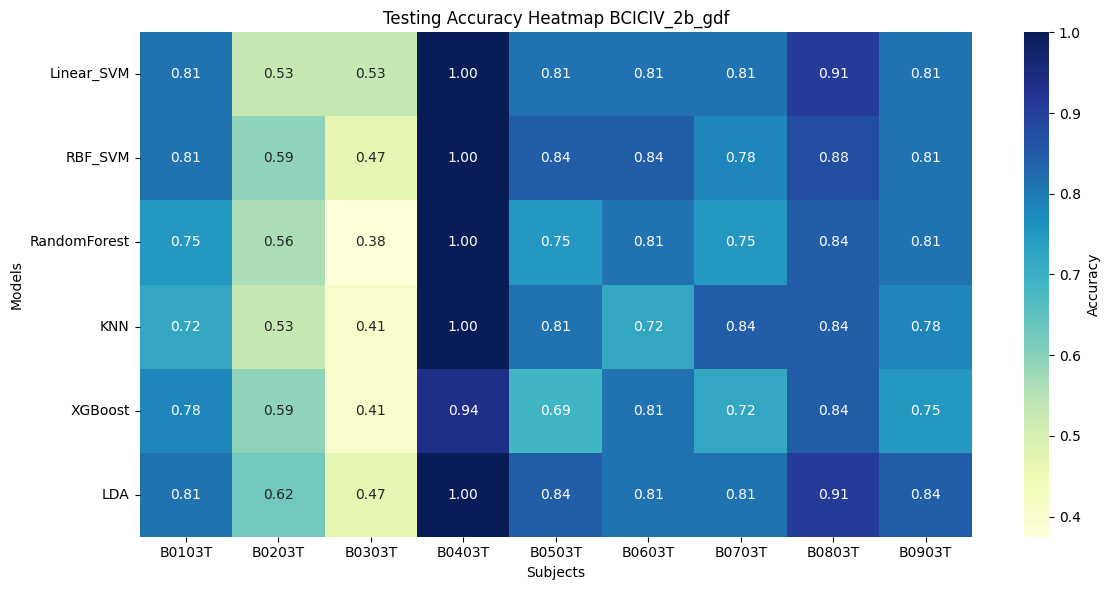

In [140]:
# Training
plt.figure(figsize=(12, 6))
df_train['Average'] = df_train.mean(axis=1)
sns.heatmap(df_train.drop('Average', axis=1), annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label': 'Accuracy'})
title = 'Training Accuracy Heatmap ' + Dataset
plt.title(title)
plt.xlabel('Subjects')
plt.ylabel('Models')
plt.tight_layout()
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
plt.savefig(name)
plt.show()
plt.close()
# Testing
plt.figure(figsize=(12, 6))
df_test['Average'] = df_train.mean(axis=1)
sns.heatmap(df_test.drop('Average', axis=1), annot=True, cmap='YlGnBu', fmt='.2f', cbar_kws={'label': 'Accuracy'})
title = 'Testing Accuracy Heatmap ' + Dataset
plt.title(title)
plt.xlabel('Subjects')
plt.ylabel('Models')
plt.tight_layout()
name = title.split(' ')
name = '_'.join(name) + ".png"
name = saveResultPath + f'./{name}'
plt.savefig(name)
plt.show()
plt.close()

# Model p-value


Significant Pairs (p < 0.05):
Linear_SVM vs XGBoost: p = 0.0208
XGBoost vs LDA: p = 0.0226

Significant Pairs (p < 0.05):
Linear_SVM vs KNN: p = 0.0497
Linear_SVM vs XGBoost: p = 0.0241
RBF_SVM vs RandomForest: p = 0.0072
RBF_SVM vs KNN: p = 0.0497
RBF_SVM vs XGBoost: p = 0.0051
RandomForest vs LDA: p = 0.0021
KNN vs LDA: p = 0.0077
XGBoost vs LDA: p = 0.0024


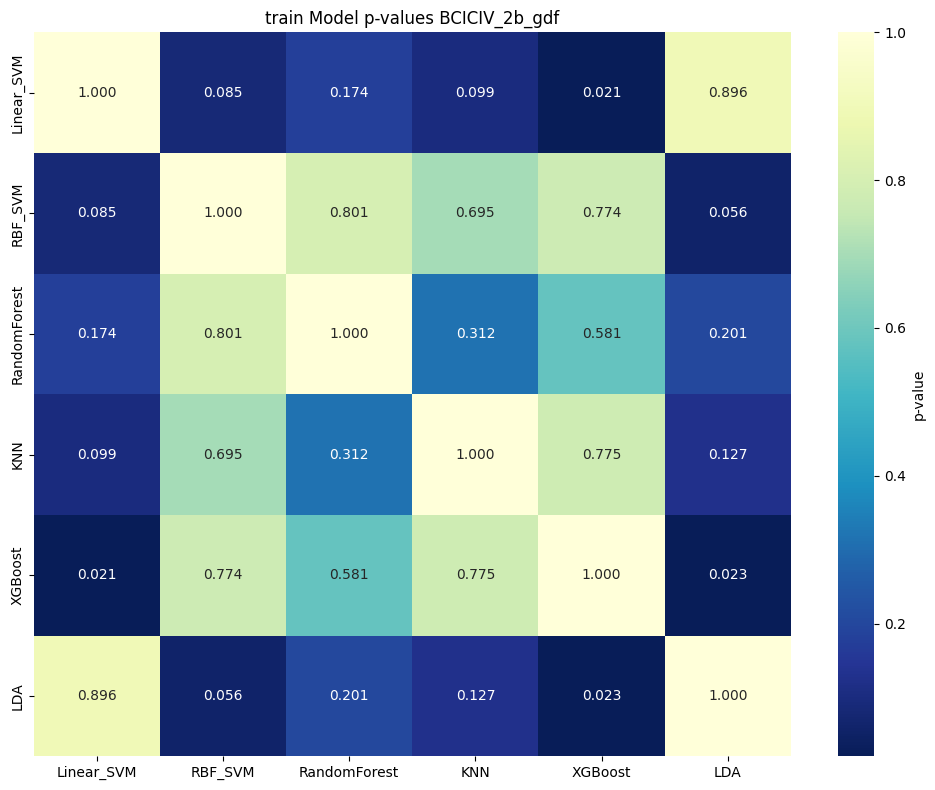

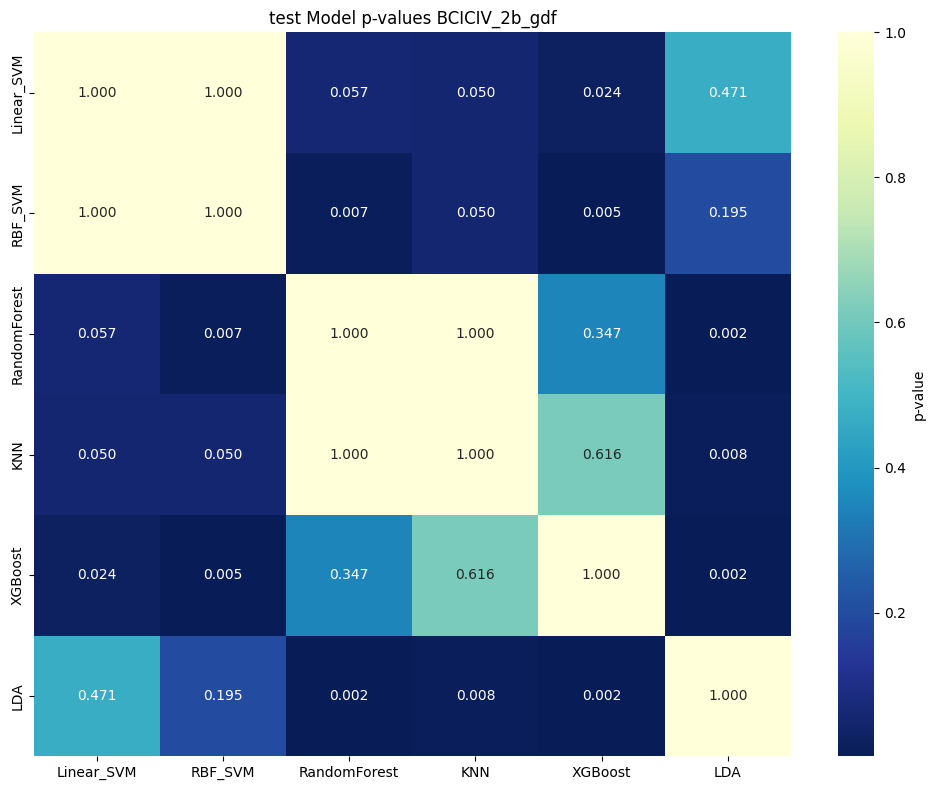

In [141]:
datas = {}
datas['train'] = {
    'Linear_SVM':   list(df_train.iloc[0][0:-1]),
    'RBF_SVM':      list(df_train.iloc[1][0:-1]),
    'RandomForest': list(df_train.iloc[2][0:-1]),
    'KNN':          list(df_train.iloc[3][0:-1]),
    'XGBoost':      list(df_train.iloc[4][0:-1]),
    'LDA':          list(df_train.iloc[5][0:-1])
}

datas['test'] = {
    'Linear_SVM':   list(df_test.iloc[0][0:-1]),
    'RBF_SVM':      list(df_test.iloc[1][0:-1]),
    'RandomForest': list(df_test.iloc[2][0:-1]),
    'KNN':          list(df_test.iloc[3][0:-1]),
    'XGBoost':      list(df_test.iloc[4][0:-1]),
    'LDA':          list(df_test.iloc[5][0:-1])
}

for idx, data in datas.items():
    model_names = list(data.keys())
    n_models = len(model_names)

    # Initialize p-value matrix
    p_matrix = np.zeros((n_models, n_models))

    for i in range(n_models):
        for j in range(n_models):
            if i == j:
                p_matrix[i, j] = 1.0
            else:
                # Perform paired t-test between model i and model j
                _, p_val = stats.ttest_rel(data[model_names[i]], data[model_names[j]])
                p_matrix[i, j] = p_val

    # Create DataFrame for better visualization
    p_df = pd.DataFrame(p_matrix, index=model_names, columns=model_names)

    # Generate Heatmap
    plt.figure(figsize=(10, 8))
    # Use a divergent or sequential color map. Darker means lower p-value (more significant)
    # We can use mask for the upper triangle if we want, but a full matrix is fine.
    # We'll highlight cells where p < 0.05
    sns.heatmap(p_df, annot=True, cmap="YlGnBu_r", fmt=".3f", cbar_kws={'label': 'p-value'})
    title = idx + ' Model p-values ' + Dataset
    plt.title(title)
    plt.tight_layout()
    name = title.split(' ')
    name = '_'.join(name) + ".png"
    name = saveResultPath + f'./{name}'
    plt.savefig(name)

    # Check for any significant differences (p < 0.05)
    significant_pairs = []
    for i in range(n_models):
        for j in range(i + 1, n_models):
            if p_matrix[i, j] < 0.05:
                significant_pairs.append((model_names[i], model_names[j], p_matrix[i, j]))

    if significant_pairs:
        print("\nSignificant Pairs (p < 0.05):")
        for m1, m2, p in significant_pairs:
            print(f"{m1} vs {m2}: p = {p:.4f}")
    else:
        print("\nNo pairs show a significant difference (p < 0.05).")

# Report Analysis (Abort)

In [142]:
# test_acc_all = {}
# test_precision_all = {}
# test_recall_all = {}
# test_f1_all = {}
# test_kappa_all = {}
# for subject in participants:
#     test_acc_all[subject] = []
#     test_precision_all[subject] = []
#     test_recall_all[subject] = []
#     test_f1_all[subject] = []
#     test_kappa_all[subject] = []

# # 計算每個人的統計指標
# for subject in participants:
#     TP = classification_results[subject][0][0]
#     TN = classification_results[subject][0][1]
#     FN = classification_results[subject][1][0]
#     FP = classification_results[subject][1][1]
#     test_trials = classification_results[subject].sum()

#     test_acc  = (TP+FP)/test_trials
#     test_precision = TP/(TP+FN)
#     test_recall = TP/(TP+TN)
#     test_f1 = (2*test_precision*test_recall)/(test_precision+test_recall)
#     test_pe = ((TP+FN)/test_trials)*((TP+TN)/test_trials)+((TN+FP)/test_trials)*((FN+FP)/test_trials)
#     test_kappa = (test_acc-test_pe)/(1-test_pe)

#     test_acc_all[subject]       = round(test_acc*100,1)
#     test_precision_all[subject] = round(test_precision*100,1)
#     test_recall_all[subject]    = round(test_recall*100,1)
#     test_f1_all[subject]        = round(test_f1,2)
#     test_kappa_all[subject]     = round(test_kappa,2)


# test_acc_all['avg']         = round(np.mean(list(test_acc_all.values())), 1)
# test_precision_all['avg']   = round(np.mean(list(test_precision_all.values())), 1)
# test_recall_all['avg']      = round(np.mean(list(test_recall_all.values())), 1)
# test_f1_all['avg']          = round(np.mean(list(test_f1_all.values())), 2)
# test_kappa_all['avg']       = round(np.mean(list(test_kappa_all.values())), 2)

# test_acc_all['std']         = round(np.std(list(test_acc_all.values())), 1)
# test_precision_all['std']   = round(np.std(list(test_precision_all.values())), 1)
# test_recall_all['std']      = round(np.std(list(test_recall_all.values())), 1)
# test_f1_all['std']          = round(np.std(list(test_f1_all.values())), 2)
# test_kappa_all['std']       = round(np.std(list(test_kappa_all.values())), 2)

# # 創建表格
# data = {
#     'Subject'  : [subject for subject in participants] + ['Avg.'] + ['Std.'],
#     'Accuracy' : [f"{test_acc_all[subject]:.1f}" for subject in participants] + [test_acc_all['avg']] + [test_acc_all['std']],
#     'Precicion': [f"{test_precision_all[subject]:.1f}" for subject in participants] + [test_precision_all['avg']] + [test_precision_all['std']],
#     'Recall'   : [f"{test_recall_all[subject]:.1f}" for subject in participants] + [test_recall_all['avg']] + [test_recall_all['std']],
#     'F1-score' : [f"{test_f1_all[subject]:.2f}" for subject in participants] + [f"{test_f1_all['avg']:.2f}"] + [test_f1_all['std']],
#     'Kappa'    : [f"{test_kappa_all[subject]:.2f}" for subject in participants] + [f"{test_kappa_all['avg']:.2f}"] + [test_kappa_all['std']]
# }

# df = pd.DataFrame(data)

# print("--- 數據表格 ---")
# print(df)

# output_filename = saveResultPath + './stat_results.csv'
# df.to_csv(
#     output_filename,
#     index=False        # 設置 index=False 來忽略 DataFrame 的索引列
# )

# print(f"\n數據已成功匯出到 '{output_filename}'，且不包含行索引。")

# Visualization (Abort)

In [143]:
# data1 = {
#     'Accuracy' : [test_acc_all[subject] for subject in participants],
#     'Precicion': [test_precision_all[subject] for subject in participants],
#     'Recall'   : [test_recall_all[subject] for subject in participants]}
# df1 = pd.DataFrame(data1)
# fig = plt.figure(figsize=(5, 4))
# sns.boxplot(data=df1, palette="Set2")
# sns.stripplot(data=df1, color="black", size=5, jitter=True) # 疊加資料點
# plt.ylabel(f'Percentage (%)')
# plt.yticks(np.arange(50, 101, step=10))
# plt.grid(axis='y')
# plt.show()
# title = 'acc_pre_rec.png'
# name = title.split(' ')
# name = '_'.join(name) + ".png"
# name = saveResultPath + f'./{name}'
# fig.savefig(name)

# data2 = {
#     'F1-score' : [test_f1_all[subject] for subject in participants],
#     'Kappa'    : [test_kappa_all[subject] for subject in participants]}
# df2 = pd.DataFrame(data2)
# fig = plt.figure(figsize=(5, 4))
# sns.boxplot(data=df2, palette="Set2")
# sns.stripplot(data=df2, color="black", size=5, jitter=True) # 疊加資料點
# plt.ylabel(f'Score')
# plt.yticks(np.arange(0, 1.1, step=0.2))
# plt.grid(axis='y')
# plt.show()
# title = 'f1_kappa.png'
# name = title.split(' ')
# name = '_'.join(name) + ".png"
# name = saveResultPath + f'./{name}'
# fig.savefig(name)
